In [71]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from PIL import Image
import os

In [72]:
# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)

Running on: cuda


In [73]:
# Remove corrupted images
for main_folder in ['train', 'test']:
    for folder in ['clean', 'muddy', 'polluted']:
        path = f'water_dataset/{main_folder}/{folder}'
        for file in os.listdir(path):
            fpath = os.path.join(path, file)
            try:
                Image.open(fpath).verify()
            except:
                print("Corrupted removed:", fpath)
                os.remove(fpath)

In [74]:
# Data preprocessing
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomResizedCrop(128, scale=(0.7, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

In [75]:
# Dataset + Dataloaders
train_dataset = datasets.ImageFolder(root='water_dataset/train', transform=train_transform)
test_dataset = datasets.ImageFolder(root='water_dataset/test', transform=test_transform)

# Split training data into train & validation
val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_ds, val_ds = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)

Classes: ['clean', 'muddy', 'polluted']


In [76]:
# --- CNN Architecture ---
class WaterCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [77]:
# --- Model, Optimizer, Scheduler ---
model = WaterCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, verbose=True
)

In [78]:
# --- Early Stopping ---
best_val_loss = float('inf')
patience = 5
trigger_times = 0
num_epochs = 25

In [79]:
# TRAINING LOOP
for epoch in range(num_epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_train_loss = total_loss / len(train_loader)
    train_acc = 100 * correct / total

    # --- Validation Phase ---
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    # --- Logging ---
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_train_loss:.4f}, Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Acc: {val_acc:.2f}%")

    # --- Scheduler & Early Stopping ---
    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss - 1e-4:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_water_cnn.pth")
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping at epoch {epoch+1}.")
            break


Epoch [1/25] | Train Loss: 0.7794, Acc: 65.57% | Val Loss: 1.0658, Acc: 34.21%
Epoch [2/25] | Train Loss: 0.5922, Acc: 76.07% | Val Loss: 0.8010, Acc: 55.26%
Epoch [3/25] | Train Loss: 0.6155, Acc: 73.11% | Val Loss: 0.6359, Acc: 73.68%
Epoch [4/25] | Train Loss: 0.5553, Acc: 78.03% | Val Loss: 0.5214, Acc: 75.00%
Epoch [5/25] | Train Loss: 0.5339, Acc: 77.38% | Val Loss: 0.6340, Acc: 75.00%
Epoch [6/25] | Train Loss: 0.5530, Acc: 76.07% | Val Loss: 0.5819, Acc: 78.95%
Epoch [7/25] | Train Loss: 0.4996, Acc: 79.02% | Val Loss: 0.5323, Acc: 77.63%
Epoch [8/25] | Train Loss: 0.4866, Acc: 77.70% | Val Loss: 0.5274, Acc: 77.63%
Epoch [9/25] | Train Loss: 0.5021, Acc: 79.67% | Val Loss: 0.5300, Acc: 78.95%
Early stopping at epoch 9.


In [80]:
# TEST EVALUATION
model.load_state_dict(torch.load("best_water_cnn.pth"))
model.eval()
test_correct, test_total = 0, 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

print(f"Test Accuracy: {100 * test_correct / test_total:.2f}%")

C:\Users\HP\AppData\Local\Temp\ipykernel_5072\2553542800.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_water_cnn.pth"))


Test Accuracy: 81.82%


In [81]:
torch.save(model.state_dict(), "water_quality_classifier.pth")

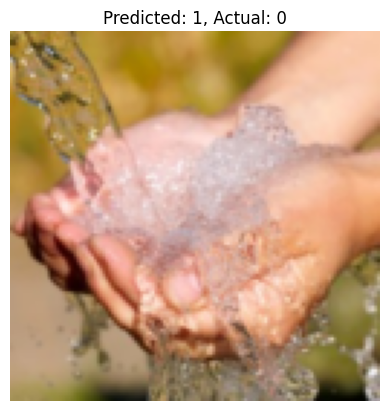

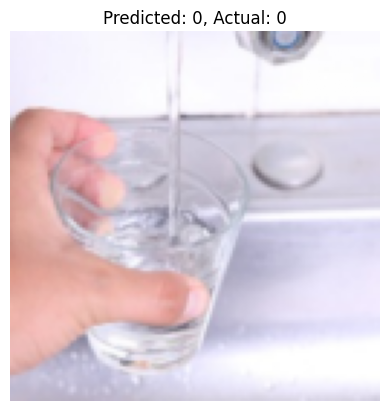

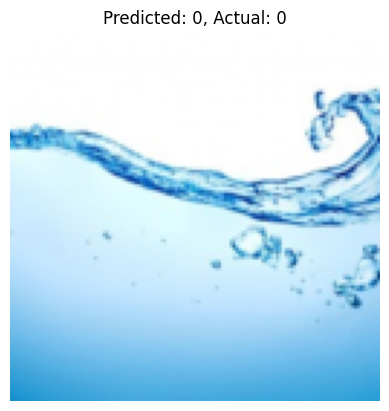

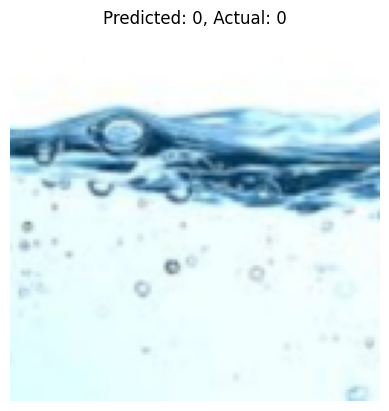

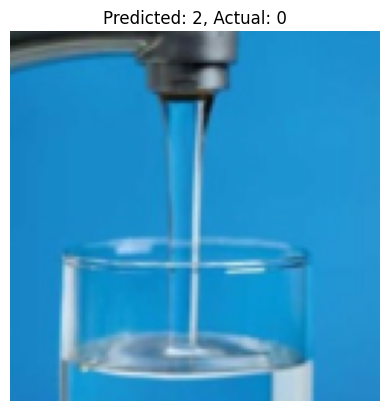

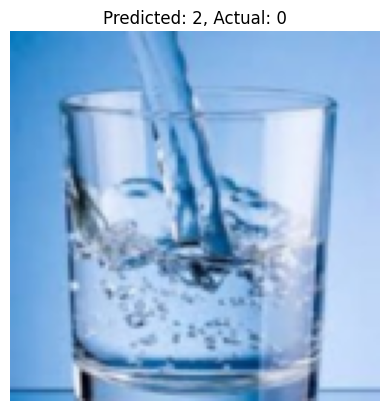

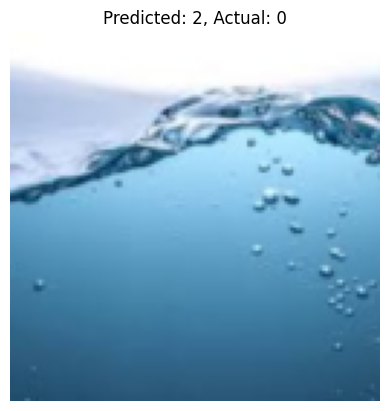

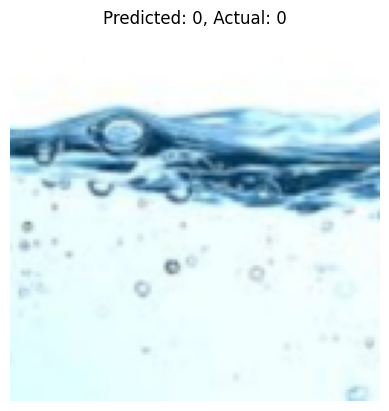

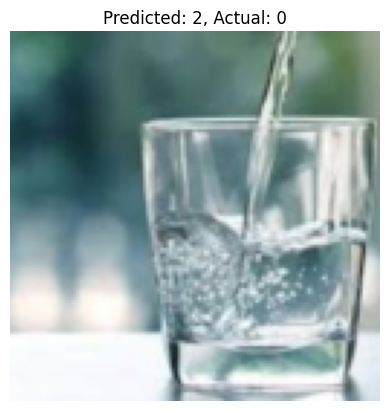

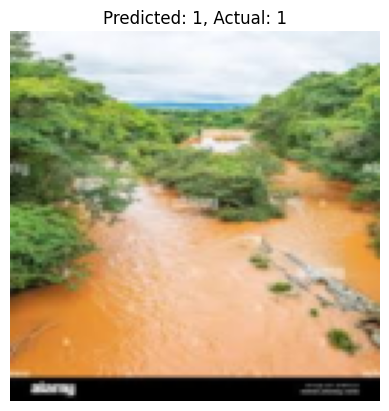

In [93]:
import torch
import matplotlib.pyplot as plt

model.eval()


for i in range(10):
    image, true_label = test_dataset[i]
    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        _, predicted = torch.max(output, 1)
        label = predicted.item()
        image = image * 0.5 + 0.5
        plt.imshow(image.permute(1, 2, 0))
        plt.title(f"Predicted: {label}, Actual: {true_label}")
        plt.axis('off')
        plt.show()